Found 1009 valid designs fitting constraints.


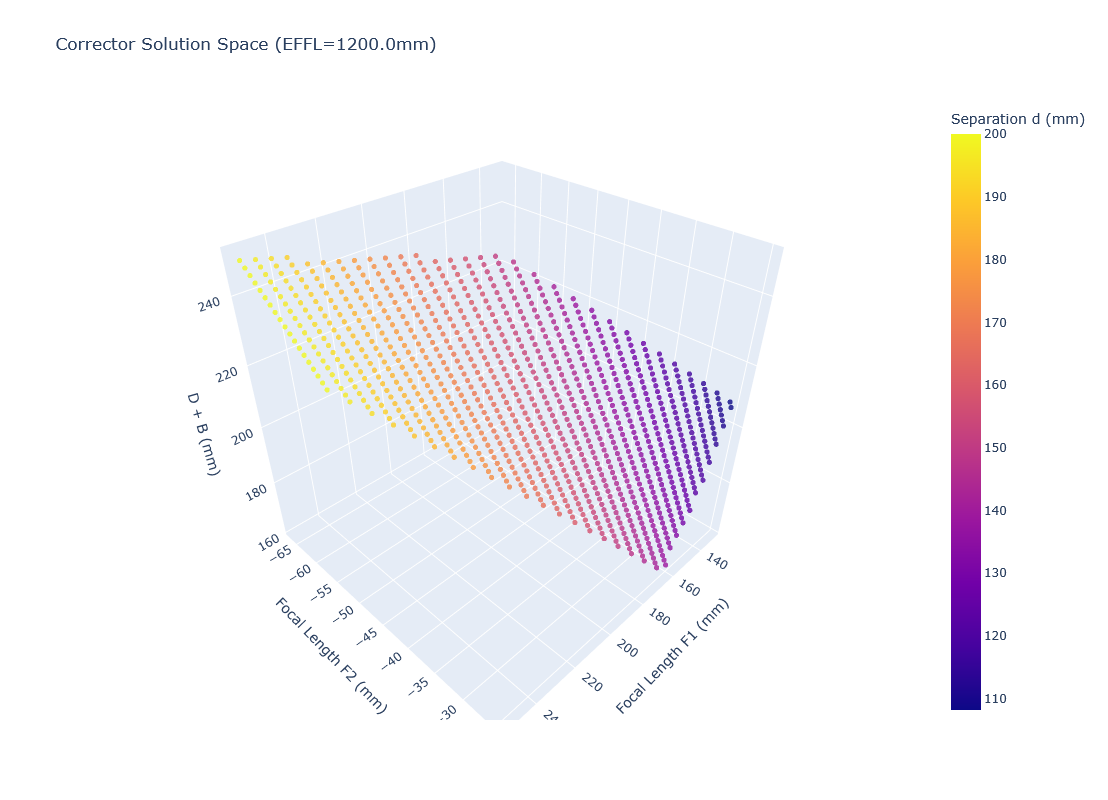

In [1]:
import numpy as np
import plotly.graph_objects as go

effl = 1200.0  
max_db = 250.0

d_range = np.linspace(50, 200, 50) 
b_range = np.linspace(20, 100, 50)

D, B = np.meshgrid(d_range, b_range)
DB_sum = D + B

denom_f1 = effl - DB_sum
with np.errstate(divide='ignore', invalid='ignore'):
    F1 = np.where(np.abs(denom_f1) > 1e-5, (D * effl) / denom_f1, np.nan)

denom_f2 = F1 - effl
with np.errstate(divide='ignore', invalid='ignore'):
    F2 = np.where(np.abs(denom_f2) > 1e-5, (effl * (F1 - D)) / denom_f2, np.nan)

mask = (
    (DB_sum <= max_db) &
    (DB_sum >= 150) &
    (np.abs(F2) > 25) &
    (B > 5) &
    np.isfinite(F1) &
    np.isfinite(F2) &
    (np.abs(F1) < 5000) &
    (np.abs(F2) < 5000)
)

points = np.column_stack((F1[mask], F2[mask], DB_sum[mask], D[mask], B[mask]))

print(f"Found {len(points)} valid designs fitting constraints.")

fig = go.Figure(data=go.Scatter3d(
    x=points[:, 0],      # F1
    y=points[:, 1],      # F2
    z=points[:, 2],      # D + B (Total Length from L1)
    mode='markers',
    marker=dict(
        size=3,
        color=points[:, 3],  # Color by Separation (D)
        colorscale='Plasma',
        colorbar=dict(title="Separation d (mm)"),
        showscale=True,
        opacity=0.8
    ),
    text=[f"d={d:.1f}, b={b:.1f}" for d, b in zip(points[:, 3], points[:, 4])],
    hovertemplate="<b>F1:</b> %{x:.1f}<br><b>F2:</b> %{y:.1f}<br><b>(D+B):</b> %{z:.1f}<br>%{text}<extra></extra>"
))

fig.update_layout(
    width=1000, height=800,
    title=f"Corrector Solution Space (EFFL={effl}mm)",
    scene=dict(
        xaxis_title='Focal Length F1 (mm)',
        yaxis_title='Focal Length F2 (mm)',
        zaxis_title='D + B (mm)',
        aspectmode='cube'
    )
)

fig.show()

In [2]:
print(f"R1 Range: {2 * np.min(np.abs(points[:, 0])):.1f} to {2 * np.max(np.abs(points[:, 0])):.1f} mm")
print(f"R2 Range: {2 * np.min(np.abs(points[:, 1])):.1f} to {2 * np.max(np.abs(points[:, 1])):.1f} mm")
print(f"D Range (Sep): {np.min(points[:, 3]):.1f} to {np.max(points[:, 3]):.1f} mm")
print(f"B Range (BFL): {np.min(points[:, 4]):.1f} to {np.max(points[:, 4]):.1f} mm")

R1 Range: 261.3 to 504.9 mm
R2 Range: 50.0 to 132.9 mm
D Range (Sep): 108.2 to 200.0 mm
B Range (BFL): 20.0 to 100.0 mm


In [3]:
points[500]

array([182.49075216, -37.11456468, 206.93877551, 151.02040816,
        55.91836735])

Found 1009 valid designs fitting constraints.


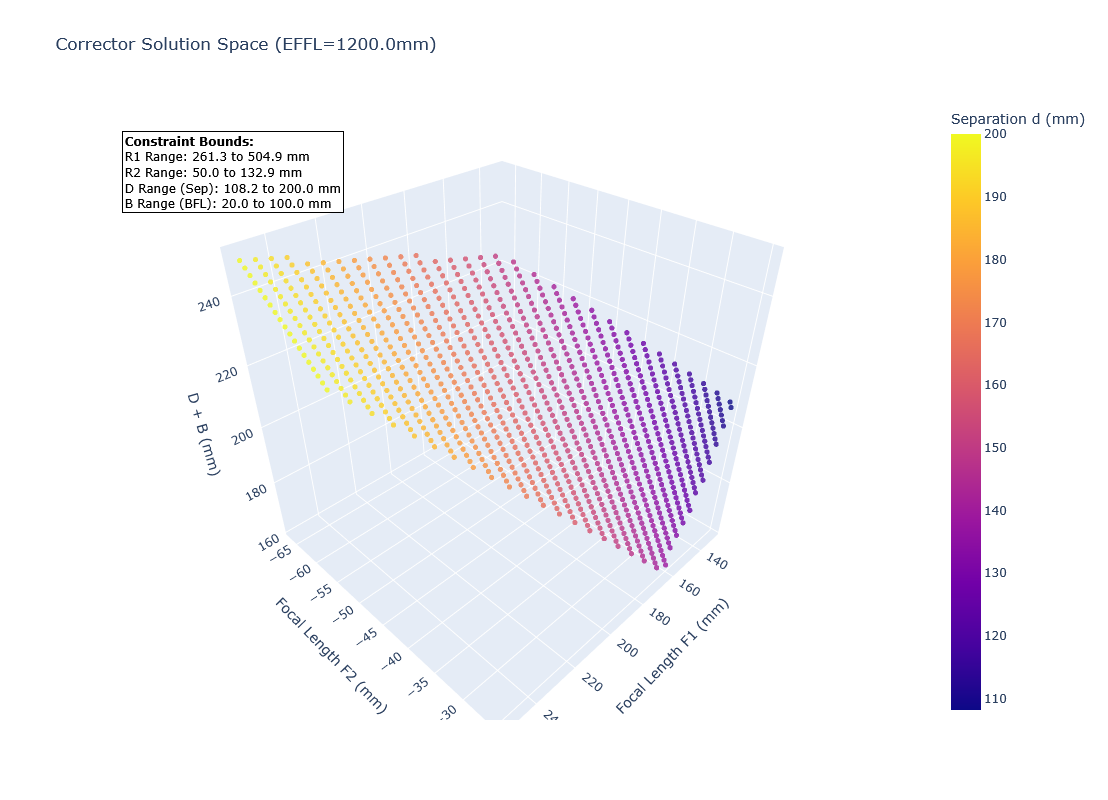

In [8]:
import numpy as np
import plotly.graph_objects as go

effl = 1200.0  
max_db = 250.0

d_range = np.linspace(50, 200, 50) 
b_range = np.linspace(20, 100, 50)

D, B = np.meshgrid(d_range, b_range)
DB_sum = D + B

denom_f1 = effl - DB_sum
with np.errstate(divide='ignore', invalid='ignore'):
    F1 = np.where(np.abs(denom_f1) > 1e-5, (D * effl) / denom_f1, np.nan)

denom_f2 = F1 - effl
with np.errstate(divide='ignore', invalid='ignore'):
    F2 = np.where(np.abs(denom_f2) > 1e-5, (effl * (F1 - D)) / denom_f2, np.nan)

mask = (
    (DB_sum <= max_db) &
    (DB_sum >= 150) &
    (np.abs(F2) > 25) &
    (B > 5) &
    np.isfinite(F1) &
    np.isfinite(F2) &
    (np.abs(F1) < 5000) & 
    (np.abs(F2) < 5000)
)

points = np.column_stack((F1[mask], F2[mask], DB_sum[mask], D[mask], B[mask]))

# --- Range Calculations ---
# Note: R = 2 * |f| is a thin-lens approximation for radius (assuming n=1.5 and plano-convex)
r1_min, r1_max = 2 * np.min(np.abs(points[:, 0])), 2 * np.max(np.abs(points[:, 0]))
r2_min, r2_max = 2 * np.min(np.abs(points[:, 1])), 2 * np.max(np.abs(points[:, 1]))
d_min, d_max = np.min(points[:, 3]), np.max(points[:, 3])
b_min, b_max = np.min(points[:, 4]), np.max(points[:, 4])

stats_text = (
    f"<b>Constraint Bounds:</b><br>"
    f"R1 Range: {r1_min:.1f} to {r1_max:.1f} mm<br>"
    f"R2 Range: {r2_min:.1f} to {r2_max:.1f} mm<br>"
    f"D Range (Sep): {d_min:.1f} to {d_max:.1f} mm<br>"
    f"B Range (BFL): {b_min:.1f} to {b_max:.1f} mm"
)

print(f"Found {len(points)} valid designs fitting constraints.")

# --- Plotting ---
fig = go.Figure(data=go.Scatter3d(
    x=points[:, 0],      # F1
    y=points[:, 1],      # F2
    z=points[:, 2],      # D + B
    mode='markers',
    marker=dict(
        size=3,
        color=points[:, 3],  # Color by Separation (D)
        colorscale='Plasma',
        colorbar=dict(title="Separation d (mm)"),
        showscale=True,
        opacity=0.8
    ),
    text=[f"d={d:.1f}, b={b:.1f}" for d, b in zip(points[:, 3], points[:, 4])],
    hovertemplate="<b>F1:</b> %{x:.1f}<br><b>F2:</b> %{y:.1f}<br><b>(D+B):</b> %{z:.1f}<br>%{text}<extra></extra>"
))

# Add the text box to the layout
fig.add_annotation(
    dict(
        xref="paper", yref="paper",
        x=0.05, y=0.95,
        showarrow=False,
        text=stats_text,
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="black",
        borderwidth=1,
        font=dict(size=12, color="black"),
        align="left"
    )
)

fig.update_layout(
    width=800, height=800,
    title=f"Corrector Solution Space (EFFL={effl}mm)",
    scene=dict(
        xaxis_title='Focal Length F1 (mm)',
        yaxis_title='Focal Length F2 (mm)',
        zaxis_title='D + B (mm)',
        aspectmode='cube'
    )
)

fig.show()

In [6]:
293.322-299.887

-6.564999999999998